In [6]:
from prefixspan import PrefixSpan

sequences = [
    [('phone',), ('case',), ('earphones',)],
    [('phone',), ('case',)],
    [('phone',), ('earphones',)],
    [('laptop',), ('mouse',), ('keyboard',)],
    [('laptop',), ('mouse',)],
]


In [8]:
ps = PrefixSpan(sequences)
patterns = ps.frequent(2)

patterns


[(3, [('phone',)]),
 (2, [('phone',), ('case',)]),
 (2, [('phone',), ('earphones',)]),
 (2, [('case',)]),
 (2, [('earphones',)]),
 (2, [('laptop',)]),
 (2, [('laptop',), ('mouse',)]),
 (2, [('mouse',)])]

In [12]:
patterns_all = ps.frequent(1)
patterns_all


[(3, [('phone',)]),
 (2, [('phone',), ('case',)]),
 (1, [('phone',), ('case',), ('earphones',)]),
 (2, [('phone',), ('earphones',)]),
 (2, [('case',)]),
 (1, [('case',), ('earphones',)]),
 (2, [('earphones',)]),
 (2, [('laptop',)]),
 (2, [('laptop',), ('mouse',)]),
 (1, [('laptop',), ('mouse',), ('keyboard',)]),
 (1, [('laptop',), ('keyboard',)]),
 (2, [('mouse',)]),
 (1, [('mouse',), ('keyboard',)]),
 (1, [('keyboard',)])]

In [13]:
def sequence_support(seq, sequences):
    count = 0
    for user_seq in sequences:
        i = 0
        for step in user_seq:
            if step == seq[i]:
                i += 1
                if i == len(seq):
                    count += 1
                    break
    return count


In [14]:
def item_probability(item, sequences):
    count = sum(
        any(item in step for step in user_seq)
        for user_seq in sequences
    )
    return count / len(sequences)


In [15]:
rules = []

for support, seq in patterns_all:
    if len(seq) < 2:
        continue

    X = seq[:-1]
    Y = seq[-1]

    support_XY = support
    support_X = sequence_support(X, sequences)

    confidence = support_XY / support_X if support_X > 0 else 0
    lift = confidence / item_probability(Y[0], sequences)

    rules.append({
        "X": X,
        "Y": Y,
        "support": support_XY,
        "confidence": confidence,
        "lift": lift,
    })


In [16]:
for r in rules:
    r["score"] = r["support"] * r["confidence"] * r["lift"]

rules_sorted = sorted(rules, key=lambda x: x["score"], reverse=True)
rules_sorted


[{'X': [('laptop',)],
  'Y': ('mouse',),
  'support': 2,
  'confidence': 1.0,
  'lift': 2.5,
  'score': 5.0},
 {'X': [('phone',)],
  'Y': ('case',),
  'support': 2,
  'confidence': 0.6666666666666666,
  'lift': 1.6666666666666665,
  'score': 2.222222222222222},
 {'X': [('phone',)],
  'Y': ('earphones',),
  'support': 2,
  'confidence': 0.6666666666666666,
  'lift': 1.6666666666666665,
  'score': 2.222222222222222},
 {'X': [('laptop',), ('mouse',)],
  'Y': ('keyboard',),
  'support': 1,
  'confidence': 0.5,
  'lift': 2.5,
  'score': 1.25},
 {'X': [('laptop',)],
  'Y': ('keyboard',),
  'support': 1,
  'confidence': 0.5,
  'lift': 2.5,
  'score': 1.25},
 {'X': [('mouse',)],
  'Y': ('keyboard',),
  'support': 1,
  'confidence': 0.5,
  'lift': 2.5,
  'score': 1.25},
 {'X': [('phone',), ('case',)],
  'Y': ('earphones',),
  'support': 1,
  'confidence': 0.5,
  'lift': 1.25,
  'score': 0.625},
 {'X': [('case',)],
  'Y': ('earphones',),
  'support': 1,
  'confidence': 0.5,
  'lift': 1.25,
  'sc

In [17]:
def recommend_next(current_seq, rules, top_k=3):
    candidates = []
    for r in rules:
        if r["X"] == current_seq:
            candidates.append((r["Y"], r["score"]))
    return sorted(candidates, key=lambda x: x[1], reverse=True)[:top_k]


In [18]:
recommend_next([('phone',), ('case',)], rules_sorted)


[(('earphones',), 0.625)]

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for r in rules_sorted:
    from_item = r["X"][-1][0]   # last item in prefix
    to_item = r["Y"][0]
    weight = r["score"]

    G.add_edge(from_item, to_item, weight=weight)


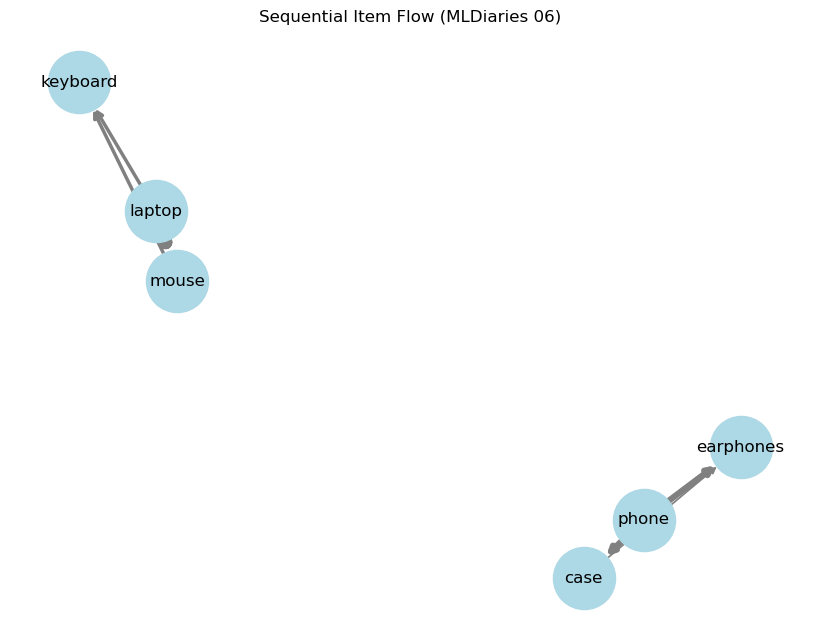

In [20]:
pos = nx.spring_layout(G, seed=42)

edges = G.edges()
weights = [G[u][v]['weight'] * 2 for u, v in edges]

plt.figure(figsize=(8, 6))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    arrows=True,
    width=weights,
    edge_color="gray"
)

plt.title("Sequential Item Flow (MLDiaries 06)")
plt.show()
